# Diarka QAOA Portfolio — Notebook 05: First Hardware Run on IBM Quantum

**Week 3, Session 2.** Goal: submit the QAOA $p = 1$ circuit (with COBYLA-converged parameters from Session 3) to a real IBM Quantum backend, wait for queue, fetch results, and compare to the noiseless simulator from earlier sessions.

This is the first session where the *quantum hardware* part of the project shows up. Three substantive differences from everything we've done so far:

1. **The execution is asynchronous.** Once the job is submitted, our local Python state stops mattering — the job sits in IBM's queue. Wait times vary from minutes to days. The notebook is structured so that you submit a job today and come back tomorrow (or whenever) to fetch results without re-running anything expensive.
2. **The circuit gets transpiled for a specific hardware topology.** IBM's heavy-hex devices have sparse qubit connectivity, so an all-to-all QUBO needs SWAP gates to route 2-qubit interactions. We'll see depth blow up substantially.
3. **The result will be noisy.** No more pristine ⟨H⟩ values to optimise against. Approximation ratio will drop from simulator's ~0.91 to something well below it, and ground-state probability will be very small. The interesting story is *how much* of the simulator signal survives.

The notebook is self-resuming: if a saved `job_id` is on disk, it skips submission and goes straight to fetch-and-analyse. To submit a new job (e.g. on a different backend), delete `data/processed/hardware_job_id.txt`.

## 0. Setup

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import warnings
import time

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=Warning, module="scipy")

from qiskit.quantum_info import SparsePauliOp
from src.qaoa import qaoa_ansatz
from src.hardware import (
    get_service, pick_backend, describe_backend,
    transpile_for_backend, submit_job,
    job_status, fetch_result, extract_counts,
)

DATA_PROCESSED = ROOT / "data" / "processed"
JOB_ID_PATH    = DATA_PROCESSED / "hardware_job_id.txt"
BACKEND_PATH   = DATA_PROCESSED / "hardware_backend_name.txt"

# Reconstruct the cost Hamiltonian saved by Session 2.
ham_data = np.load(DATA_PROCESSED / "hamiltonian.npz", allow_pickle=False)
H = SparsePauliOp.from_list(list(zip(ham_data["pauli_labels"], ham_data["pauli_coeffs"])))
ISING_OFFSET     = float(ham_data["ising_offset"])
E_GROUND         = float(ham_data["ground_energy"])
GROUND_BITS      = str(ham_data["ground_bitstring"])
GROUND_SELECTION = ham_data["ground_selection"].astype(int)
ENERGIES         = ham_data["sorted_energies"]
BITSTRINGS       = ham_data["sorted_bitstrings"]
E_MAX            = float(ENERGIES[-1])
TICKERS          = tuple(str(t) for t in ham_data["tickers"])

# Pull COBYLA-converged p=1 parameters from Session 3.
qaoa_data = np.load(DATA_PROCESSED / "qaoa_simulator_results.npz", allow_pickle=False)
P1_PARAMS    = qaoa_data["p1_params"]
P1_SIM_ENERGY = float(qaoa_data["p1_energy"])
P1_SIM_RATIO  = float(qaoa_data["p1_ratio"])
P1_SIM_COUNTS = dict(zip(
    [str(b) for b in qaoa_data["p1_count_bitstrings"]],
    [int(c) for c in qaoa_data["p1_count_values"]],
))
SIM_SHOTS = int(qaoa_data["shots"])

print(f"Hamiltonian:              {len(H)} Pauli terms on {H.num_qubits} qubits")
print(f"Ground-state energy:      {E_GROUND:+.4f}  (target)")
print(f"Highest energy:           {E_MAX:+.4f}")
print(f"COBYLA p=1 params:        γ = {P1_PARAMS[0]:+.4f}, β = {P1_PARAMS[1]:+.4f}")
print(f"Simulator ⟨H⟩ at p=1:     {P1_SIM_ENERGY:+.4f}")
print(f"Simulator approx ratio:   {P1_SIM_RATIO:.3f}")

Hamiltonian:              36 Pauli terms on 8 qubits
Ground-state energy:      -1.4436  (target)
Highest energy:           +8.1419
COBYLA p=1 params:        γ = +0.5112, β = +1.3395
Simulator ⟨H⟩ at p=1:     -0.8845
Simulator approx ratio:   0.942


## 1. Connect to IBM Quantum and pick a backend

The first call to `QiskitRuntimeService()` reads the API token you saved earlier (typically via `QiskitRuntimeService.save_account(...)` in Week 1 setup). If this fails, the error message will tell you exactly how to fix it.

`least_busy(...)` selects the queue with the fewest pending jobs — usually the fastest path to a result. The free tier currently exposes 127-qubit Eagle r3 devices (`ibm_brisbane`, `ibm_kyoto`, `ibm_osaka` and others); any of them works for an 8-qubit circuit.

In [2]:
service = get_service()
backend = pick_backend(service, min_qubits=H.num_qubits)
print(describe_backend(backend))
backends = service.backends()
print(f"Account sees {len(backends)} backends total:")
print(f"{'name':<25}  {'qubits':>6}  {'sim':>5}  {'pending':>8}  {'oper.':>5}")
print("-" * 60)
for b in backends:
    try:
        cfg = b.configuration()
        st = b.status()
        print(f"{b.name:<25}  {cfg.n_qubits:>6}  {str(cfg.simulator):>5}  {st.pending_jobs:>8}  {str(st.operational):>5}")
    except Exception as e:
        print(f"{b.name:<25}  (error: {e})")

qiskit_runtime_service.__init__:WARNING:2026-05-29 19:32:09,243: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-29 19:32:09,758: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-29 19:32:11,076: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-29 19:32:11,242: Loading instance: open-instance, plan: open


Backend:        ibm_marrakesh
Qubits:         156
Basis gates:    cz, id, rz, sx, x
Pending jobs:   0
Operational:    True
Account sees 3 backends total:
name                       qubits    sim   pending  oper.
------------------------------------------------------------
ibm_marrakesh                 156  False         0   True
ibm_kingston                  156  False         0   True
ibm_fez                       156  False         0   True


## 2. Transpile the circuit

Three things happen during transpilation:

- **Parameter binding.** The symbolic γ, β are replaced with the COBYLA-converged numerical values.
- **Gate decomposition.** `PauliEvolutionGate` is expanded into the backend's native basis (typically `rz`, `sx`, `x`, `ecr` on Eagle devices).
- **Qubit routing.** The 8 logical qubits are mapped onto 8 of the backend's physical qubits, and SWAP gates are inserted to make 2-qubit interactions match the device's connectivity.

The report below tells us the cost in terms of depth and 2-qubit gate count. With modern Eagle ECR fidelities around 99%, the surviving-shot fraction is roughly $0.99^{n_{2Q}}$, so 90 ECR gates gives about 40% clean signal — enough to see structure in the histogram.

In [3]:
ansatz = qaoa_ansatz(H, p=1)
print(f"Untranspiled QAOA ansatz: {ansatz.num_qubits} qubits, depth {ansatz.depth()}")
print(f"Ops:                       {dict(ansatz.count_ops())}")
print()

transpiled, report = transpile_for_backend(
    ansatz,
    parameters=P1_PARAMS,
    backend=backend,
    optimization_level=3,
)
print(f"Transpiled for {report.backend_name}:")
print(f"  depth:           {report.depth}")
print(f"  2-qubit gates:   {report.n_2q_gates}")
print(f"  1-qubit gates:   {report.n_1q_gates}")
print(f"  qubits used:     {report.n_qubits_used}  (of which 8 carry the logical computation)")
print(f"  gate breakdown:  {report.gate_counts}")
print()

# Rough estimate of the surviving-shot fraction at typical Eagle ECR fidelities.
ecr_fidelity = 0.99
clean_fraction = ecr_fidelity ** report.n_2q_gates
print(f"  est. clean shots @ ECR fidelity {ecr_fidelity}: {clean_fraction:.1%}")

Untranspiled QAOA ansatz: 8 qubits, depth 3
Ops:                       {'h': 8, 'rx': 8, 'barrier': 3, 'PauliEvolution': 1}

Transpiled for ibm_marrakesh:
  depth:           241
  2-qubit gates:   107
  1-qubit gates:   401
  qubits used:     156  (of which 8 carry the logical computation)
  gate breakdown:  {'sx': 209, 'rz': 185, 'cz': 107, 'measure': 8, 'x': 7, 'barrier': 4}

  est. clean shots @ ECR fidelity 0.99: 34.1%


## 3. Submit (or resume) the job

If a `job_id` is already saved from a previous run of this notebook, we skip submission and use the existing one. To force a fresh submission, delete `data/processed/hardware_job_id.txt`.

In [4]:
SHOTS = 4096

if JOB_ID_PATH.exists():
    job_id        = JOB_ID_PATH.read_text().strip()
    saved_backend = BACKEND_PATH.read_text().strip() if BACKEND_PATH.exists() else "(unknown)"
    print(f"Existing job_id found on disk:")
    print(f"  job_id:  {job_id}")
    print(f"  backend: {saved_backend}")
    print(f"\nSkipping submission. Delete {JOB_ID_PATH.name} to force a new submission.")
else:
    print(f"Submitting {SHOTS} shots to {backend.name}...")
    job = submit_job(transpiled, backend, shots=SHOTS)
    job_id = job.job_id()
    JOB_ID_PATH.write_text(job_id)
    BACKEND_PATH.write_text(backend.name)
    print(f"  job_id:  {job_id}")
    print(f"  backend: {backend.name}")
    print(f"  saved to {JOB_ID_PATH.relative_to(ROOT)}")

Existing job_id found on disk:
  job_id:  d8ctfudmdsks73d31h70
  backend: ibm_marrakesh

Skipping submission. Delete hardware_job_id.txt to force a new submission.


## 4. Wait for the job, then fetch results

We poll the status briefly. If the job hasn't completed within a reasonable time, the cell exits politely with the job ID — re-run from this point later to pick up where we left off.

In [5]:
POLL_TIMEOUT_SECONDS = 600     # cap how long we'll wait in this cell
POLL_INTERVAL_SECONDS = 30

start = time.time()
status = job_status(job_id, service=service)
print(f"Initial status: {status}")

while status not in ("DONE", "CANCELLED", "ERROR") and (time.time() - start) < POLL_TIMEOUT_SECONDS:
    time.sleep(POLL_INTERVAL_SECONDS)
    status = job_status(job_id, service=service)
    elapsed = time.time() - start
    print(f"  [{elapsed:6.0f}s] status: {status}")

print(f"\nFinal status: {status}")
result_available = (status == "DONE")

Initial status: QUEUED
  [    31s] status: QUEUED
  [    61s] status: QUEUED
  [    92s] status: QUEUED
  [   122s] status: QUEUED
  [   153s] status: DONE

Final status: DONE


In [6]:
if result_available:
    result = fetch_result(job_id, service=service)
    counts = extract_counts(result)
    print(f"Fetched results: {sum(counts.values())} shots across {len(counts)} unique bitstrings.")
else:
    print(f"Job is still {status}. Re-run this cell and the cells below once it reaches DONE.")
    print(f"Saved job_id: {job_id}")

Fetched results: 4096 shots across 254 unique bitstrings.


## 5. Analyse the hardware results

All cells below are guarded by `result_available`. If the job isn't done yet, they print a single-line skip message and do nothing else, so you can re-run the entire notebook safely without losing anything.

In [7]:
if not result_available:
    print("Results not yet available — skipping analysis cells.")
else:
    # Helper: Ising energy of any bitstring against the saved spectrum.
    def energy_of(bits: str) -> float:
        b = np.array([int(c) for c in reversed(bits)], dtype=int)
        idx = np.where(np.all(BITSTRINGS == b, axis=1))[0]
        return float(ENERGIES[idx[0]]) if len(idx) else float("nan")

    # ⟨H⟩ from the empirical distribution: ∑ p(b) · E(b).
    hw_shots = sum(counts.values())
    hw_energy = sum((c / hw_shots) * energy_of(bits) for bits, c in counts.items())

    # Approximation ratio relative to simulator's best.
    hw_ratio = (E_MAX - hw_energy) / (E_MAX - E_GROUND)

    # Probability of ground state.
    hw_ground_prob = counts.get(GROUND_BITS, 0) / hw_shots

    # Best sampled energy.
    hw_best = min(energy_of(b) for b in counts)

    print(f"{'metric':<28} {'simulator':>14} {'hardware':>14}")
    print("-" * 58)
    print(f"{'⟨H⟩':<28} {P1_SIM_ENERGY:>+14.4f} {hw_energy:>+14.4f}")
    print(f"{'approximation ratio':<28} {P1_SIM_RATIO:>14.3f} {hw_ratio:>14.3f}")
    print(f"{'P(ground state)':<28} {P1_SIM_COUNTS.get(GROUND_BITS, 0)/SIM_SHOTS:>14.3%} {hw_ground_prob:>14.3%}")
    print(f"{'best sampled energy':<28} {min(energy_of(b) for b in P1_SIM_COUNTS):>+14.4f} {hw_best:>+14.4f}")
    print(f"{'unique bitstrings':<28} {len(P1_SIM_COUNTS):>14d} {len(counts):>14d}")

metric                            simulator       hardware
----------------------------------------------------------
⟨H⟩                                 -0.8845        -0.5835
approximation ratio                   0.942          0.910
P(ground state)                      0.830%         0.586%
best sampled energy                 -1.4436        -1.4436
unique bitstrings                       208            254


### Bitstring distribution: hardware vs simulator

Two histograms over the same Ising energy axis. The simulator should concentrate sharply near low energies; the hardware should be wider, with mass leaking into mid- and high-energy regions due to noise.

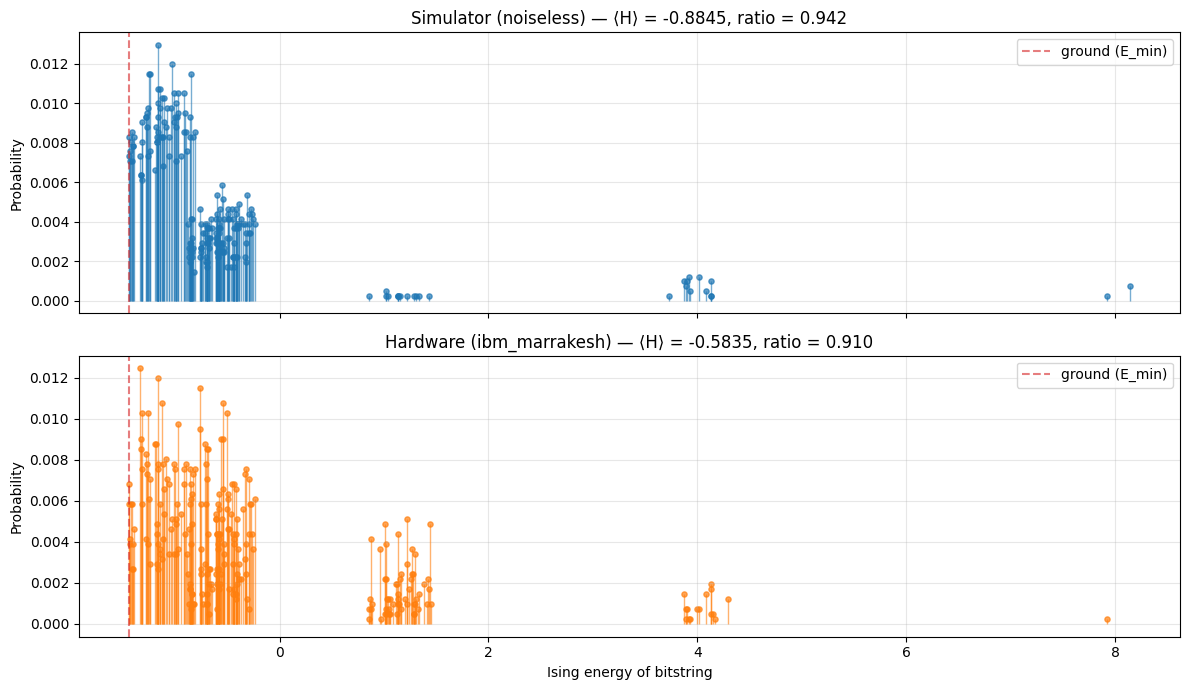

In [8]:
if result_available:
    sim_energies = np.array([energy_of(b) for b in P1_SIM_COUNTS])
    sim_probs    = np.array([c / SIM_SHOTS for c in P1_SIM_COUNTS.values()])

    hw_energies = np.array([energy_of(b) for b in counts])
    hw_probs    = np.array([c / hw_shots for c in counts.values()])

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].vlines(sim_energies, 0, sim_probs, color="#1f77b4", alpha=0.6, lw=1)
    axes[0].scatter(sim_energies, sim_probs, s=14, color="#1f77b4", alpha=0.7)
    axes[0].axvline(E_GROUND, color="#d62728", linestyle="--", alpha=0.6, label=f"ground (E_min)")
    axes[0].set_ylabel("Probability")
    axes[0].set_title(f"Simulator (noiseless) — ⟨H⟩ = {P1_SIM_ENERGY:+.4f}, ratio = {P1_SIM_RATIO:.3f}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].vlines(hw_energies, 0, hw_probs, color="#ff7f0e", alpha=0.6, lw=1)
    axes[1].scatter(hw_energies, hw_probs, s=14, color="#ff7f0e", alpha=0.7)
    axes[1].axvline(E_GROUND, color="#d62728", linestyle="--", alpha=0.6, label=f"ground (E_min)")
    axes[1].set_xlabel("Ising energy of bitstring")
    axes[1].set_ylabel("Probability")
    axes[1].set_title(f"Hardware ({backend.name if not BACKEND_PATH.exists() else BACKEND_PATH.read_text().strip()}) — ⟨H⟩ = {hw_energy:+.4f}, ratio = {hw_ratio:.3f}")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping — no results yet.")

### Top sampled portfolios from hardware

The most-frequently-observed bitstrings, translated back to portfolio selections.

In [9]:
if result_available:
    top = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:10]
    print(f"\n{'bitstring':>10}  {'card':>4}  {'energy':>9}  {'portfolio obj':>14}  {'prob':>7}  selected assets")
    print("-" * 95)
    for bits, c in top:
        x = np.array([int(ch) for ch in reversed(bits)], dtype=int)
        cardinality = int(x.sum())
        energy = energy_of(bits)
        obj    = energy + ISING_OFFSET
        prob   = c / hw_shots
        picks  = ", ".join(t for t, b in zip(TICKERS, x) if b) if cardinality > 0 else "(none)"
        mark   = "  ← ground state" if bits == GROUND_BITS else ""
        print(f"{bits:>10}  {cardinality:>4}  {energy:>+9.4f}  {obj:>+14.4f}  {prob:>6.1%}  {picks}{mark}")
else:
    print("Skipping — no results yet.")


 bitstring  card     energy   portfolio obj     prob  selected assets
-----------------------------------------------------------------------------------------------
  01000111     4    -1.3395         -0.1632    1.2%  HSBA.L, AZN.L, SHEL.L, VOD.L
  01001110     4    -1.1624         +0.0139    1.2%  AZN.L, SHEL.L, ULVR.L, VOD.L
  01001111     5    -0.7611         +0.4152    1.1%  HSBA.L, AZN.L, SHEL.L, ULVR.L, VOD.L
  01111010     5    -0.5395         +0.6368    1.1%  AZN.L, ULVR.L, RIO.L, BT-A.L, VOD.L
  01100110     4    -1.1214         +0.0549    1.1%  AZN.L, SHEL.L, BT-A.L, VOD.L
  11000111     5    -0.5081         +0.6682    1.0%  HSBA.L, AZN.L, SHEL.L, VOD.L, DGE.L
  01010101     4    -1.3178         -0.1415    1.0%  HSBA.L, SHEL.L, RIO.L, VOD.L
  01101001     4    -1.2586         -0.0823    1.0%  HSBA.L, ULVR.L, BT-A.L, VOD.L
  10101100     4    -0.9726         +0.2037    1.0%  SHEL.L, ULVR.L, BT-A.L, DGE.L
  01010111     5    -0.7579         +0.4184    1.0%  HSBA.L, AZN.L, SHE

## 6. Persist hardware results

In [10]:
if result_available:
    np.savez(
        DATA_PROCESSED / "hardware_results.npz",
        job_id=job_id,
        backend_name=BACKEND_PATH.read_text().strip() if BACKEND_PATH.exists() else backend.name,
        shots=hw_shots,
        bitstrings=np.array(list(counts.keys())),
        counts=np.array(list(counts.values())),
        hw_energy=hw_energy,
        hw_ratio=hw_ratio,
        hw_ground_prob=hw_ground_prob,
        hw_best_energy=hw_best,
        transp_depth=report.depth,
        transp_n_2q=report.n_2q_gates,
        params=P1_PARAMS,
    )
    print(f"Saved {(DATA_PROCESSED / 'hardware_results.npz').relative_to(ROOT)}")
else:
    print("Skipping — no results to persist.")

Saved data/processed/hardware_results.npz


## Session 2 (Week 3) — wrap-up

What we have at this point depends on whether your job has completed:

- **If yes:** a hardware-vs-simulator comparison plot, a top-bitstrings table, and persisted hardware counts ready for the polish phase. The gap between simulator ratio (~0.91) and hardware ratio is the headline number to put in the blog post and on LinkedIn.
- **If not yet:** the job ID is saved to `data/processed/hardware_job_id.txt`. Come back when the IBM Quantum queue shows your job as DONE (check at https://quantum.ibm.com), and re-run cells from Section 4 downwards. Nothing earlier needs to be re-executed.

**Next session (Week 3, Session 3):** statistical robustness — repeat the simulator QAOA at p = 1, 2, 3 with N = 10 different random seeds at each depth, plot approximation-ratio distributions with error bars. That gives us defensible claims for the writeup ("at p = 3 the approximation ratio is X ± Y across 10 random initialisations") rather than the n = 1 results from Session 3.